<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W03_%5BMLP__Car_Efficiency_Prediction%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown --id 1qiUDDoYyRLBiKOoYWdFl_5WByHE8Cugu

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qiUDDoYyRLBiKOoYWdFl_5WByHE8Cugu
To: /content/Auto_MPG_data.csv
100% 15.4k/15.4k [00:00<00:00, 44.5MB/s]


# ***Car Efficiency Prediction***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Seeding all random values to get the consistent values
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
  torch.cuda.manual_seed(random_state)
# Device's settings for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Read dataset
carset = pd.read_csv("/content/Auto_MPG_data.csv")
carset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Europe        392 non-null    int64  
 8   Japan         392 non-null    int64  
 9   USA           392 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 30.8 KB


In [ ]:
# Preprocessing

# Split X, y
X = carset.drop(columns="MPG")
y = carset["MPG"].values

# Train test and val split
test_size = 0.125
val_size = 0.2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_size, random_state=random_state, shuffle=is_shuffle)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_size, random_state=random_state,shuffle=is_shuffle)

# Input Normalization
normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)
X_val= normalizer.transform(X_val)
X_test = normalizer.transform(X_test)

# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



In [ ]:
# Construct DataLoader
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

batch_size = 32
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=True)



In [ ]:
# Construct MLP network
class MLP(nn.Module):
  def __init__(self, input_dims, hidden_dims, output_dims):
    super().__init__()
    self.linear1 = nn.Linear(input_dims, hidden_dims)
    self.linear2 = nn.Linear(hidden_dims, hidden_dims)
    self.output = nn.Linear(hidden_dims, output_dims)

  def forward(self, x):
    x = self.linear1(x) #Input to first hidden layer
    x = F.gelu(x) #First hidden layer to activation function
    x = self.linear2(x) #First activation to second hidden layer
    x = F.gelu(x) #to second activation function
    out = self.output(x) #to output
    return out.squeeze(1) #remove dimensions which equals to 1

input_dims = X.shape[1]
hidden_dims = 64
output_dims = 1

model = MLP(input_dims=input_dims,
            hidden_dims=hidden_dims,
            output_dims=output_dims).to(device)



In [ ]:
# Loss and Optimizer
lr = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
# Construct R^2 score function
def r_squared(y_hat, y):
  y_hat = torch.Tensor(y_hat).to(device)
  y = torch.Tensor(y).to(device)
  mean_true = torch.mean(y)
  ss_res = torch.sum((y - y_hat)**2)
  ss_rot = torch.sum((y - mean_true)**2)
  r2 = 1 - (ss_res / ss_rot)
  return r2


In [ ]:
# Training
epochs = 100
train_losses = []
train_r2 = []
val_losses = []
val_r2 = []
for epoch in range(epochs):
  # Training part
  train_loss = 0.0
  train_target = []
  train_predict = []
  model.train()

  for X_samples, y_samples in train_loader:
    X_samples = X_samples.to(device)
    y_samples = y_samples.to(device)
    optimizer.zero_grad()
    outputs = model(X_samples)
    train_predict += outputs.tolist() #Like append to list
    train_target += y_samples.tolist()
    loss = criterion(outputs, y_samples)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_r2.append(r_squared(train_predict, train_target))
  model.eval()

  # Evaluating part
  val_loss = 0.0
  val_target = []
  val_predict = []
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)
      outputs = model(X_samples)
      val_predict += outputs.tolist()
      val_target += y_samples.tolist()
      loss = criterion(outputs, y_samples)
      val_loss += loss.item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_r2.append(r_squared(val_predict, val_target))
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')


\ nEPOCH 1:\ tTraining loss : 549.238	Validation loss : 376.897
\ nEPOCH 2:\ tTraining loss : 189.761	Validation loss : 88.291
\ nEPOCH 3:\ tTraining loss : 53.926	Validation loss : 28.500
\ nEPOCH 4:\ tTraining loss : 26.776	Validation loss : 17.013
\ nEPOCH 5:\ tTraining loss : 15.571	Validation loss : 12.654
\ nEPOCH 6:\ tTraining loss : 12.560	Validation loss : 8.459
\ nEPOCH 7:\ tTraining loss : 10.209	Validation loss : 6.579
\ nEPOCH 8:\ tTraining loss : 7.881	Validation loss : 5.853
\ nEPOCH 9:\ tTraining loss : 7.877	Validation loss : 7.786
\ nEPOCH 10:\ tTraining loss : 7.583	Validation loss : 5.865
\ nEPOCH 11:\ tTraining loss : 7.420	Validation loss : 6.083
\ nEPOCH 12:\ tTraining loss : 7.862	Validation loss : 5.586
\ nEPOCH 13:\ tTraining loss : 7.942	Validation loss : 5.753
\ nEPOCH 14:\ tTraining loss : 7.128	Validation loss : 6.659
\ nEPOCH 15:\ tTraining loss : 7.049	Validation loss : 6.524
\ nEPOCH 16:\ tTraining loss : 6.867	Validation loss : 5.405
\ nEPOCH 17:\ tTra

In [ ]:
# Model Evaluation
model.eval()
with torch.no_grad():
  y_pred = model(X_test)
  test_set_r2 = r_squared(y_pred, y_test)
  print ('Evaluation on test set :')
  print (f'R2: { test_set_r2 }')

Evaluation on test set :
R2: 0.8570410013198853


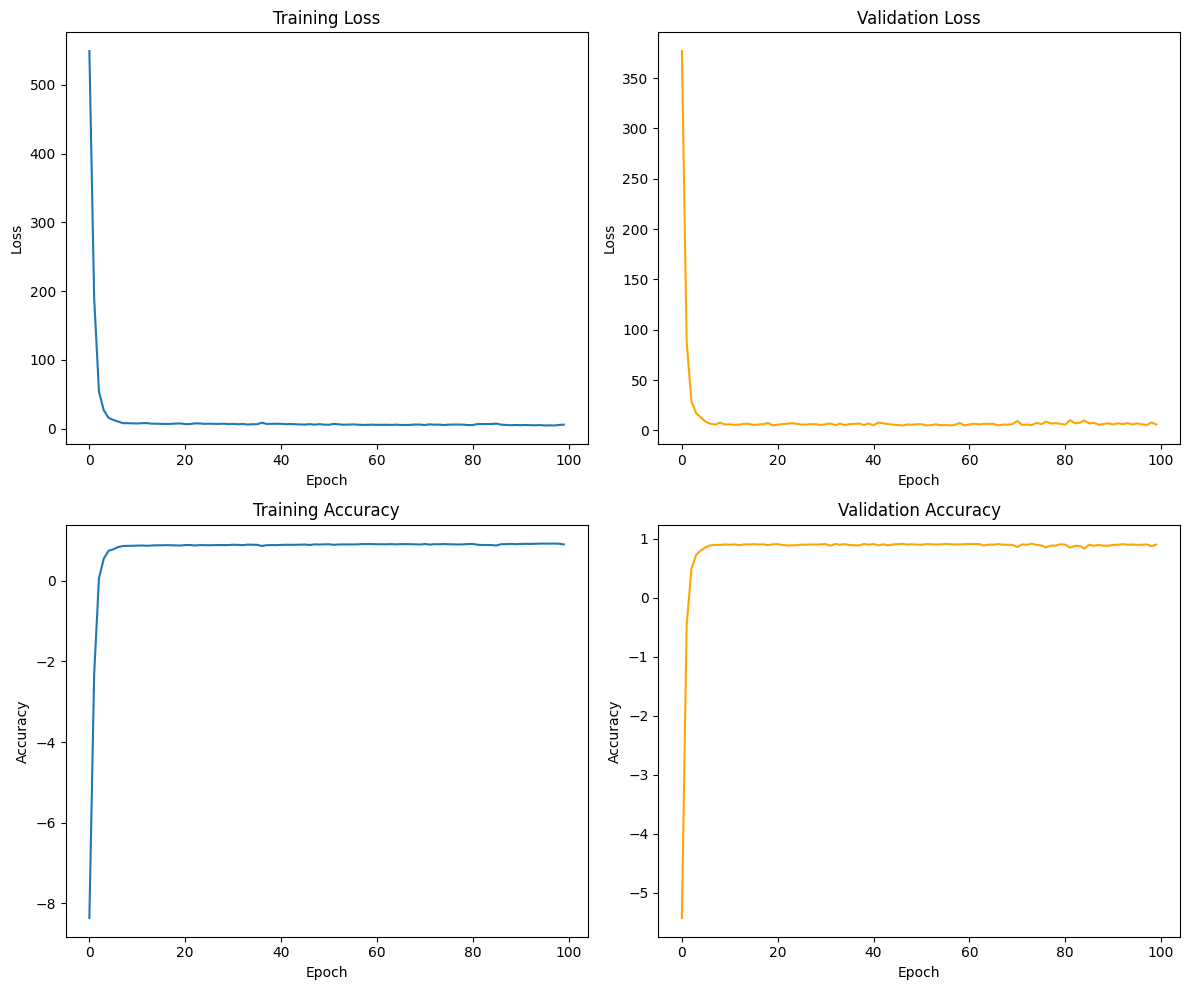

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_r2)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_r2, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

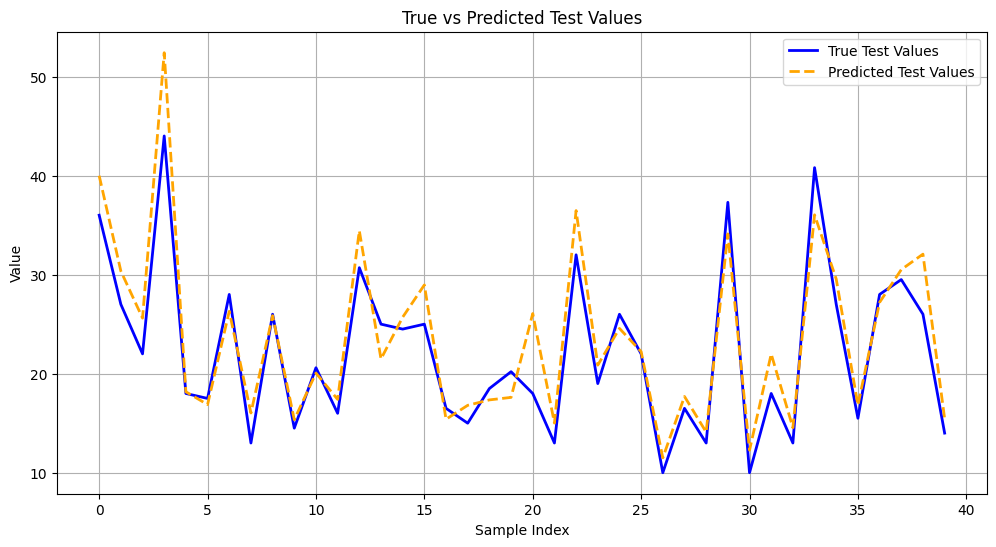

In [ ]:
import matplotlib.pyplot as plt
import torch

# Set the model to evaluation mode
model.eval()
with torch.no_grad():
    # Get predictions from the model
    y_pred = model(X_test)

    # Convert predictions and true values to CPU and detach from computation graph if using GPU
    y_pred_np = y_pred.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Plot line chart
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_np, label='True Test Values', color='blue', linewidth=2)
    plt.plot(y_pred_np, label='Predicted Test Values', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.title('True vs Predicted Test Values')
    plt.legend()
    plt.grid(True)
    plt.show()


# **Linear Regression (Testing)**

In [ ]:
class LinearRegression(nn.Module):
    def __init__(self, input_dims):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_dims, 1)

    # Corrected indentation for forward function
    def forward(self, x):
        x = self.linear(x)
        return x.squeeze(1)

LRegression_model = LinearRegression(X.shape[1])
lr = 0.01
# Loss and Optimal
L_criterion = nn.MSELoss()
L_optimizer = torch.optim.SGD(LRegression_model.parameters(), lr=lr)

# Training
epochs = 100
train_losses = []
train_r2 = []
val_losses = []
val_r2 = []
for epoch in range(epochs):
  # Training part
  train_loss = 0.0
  train_target = []
  train_predict = []
  LRegression_model.train()

  for X_samples, y_samples in train_loader:
    X_samples = X_samples.to(device)
    y_samples = y_samples.to(device)
    L_optimizer.zero_grad()
    outputs = LRegression_model(X_samples)
    train_predict += outputs.tolist() #Like append to list
    train_target += y_samples.tolist()
    loss = L_criterion(outputs, y_samples)
    loss.backward()
    L_optimizer.step()
    train_loss += loss.item()

  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_r2.append(r_squared(train_predict, train_target))
  LRegression_model.eval()

  # Evaluating part
  val_loss = 0.0
  val_target = []
  val_predict = []
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)
      outputs = LRegression_model(X_samples)
      val_predict += outputs.tolist()
      val_target += y_samples.tolist()
      loss = L_criterion(outputs, y_samples)
      val_loss += loss.item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_r2.append(r_squared(val_predict, val_target))
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')
# Model Evaluation
LRegression_model.eval()
with torch.no_grad():
  y_pred = LRegression_model (X_test)
  test_set_r2 = r_squared(y_pred, y_test)
  print ('Evaluation on test set :')
  print (f'R2: { test_set_r2 }')

\ nEPOCH 1:\ tTraining loss : 505.101	Validation loss : 427.674
\ nEPOCH 2:\ tTraining loss : 343.735	Validation loss : 301.457
\ nEPOCH 3:\ tTraining loss : 241.830	Validation loss : 215.136
\ nEPOCH 4:\ tTraining loss : 171.956	Validation loss : 162.662
\ nEPOCH 5:\ tTraining loss : 122.312	Validation loss : 116.735
\ nEPOCH 6:\ tTraining loss : 90.589	Validation loss : 84.482
\ nEPOCH 7:\ tTraining loss : 64.719	Validation loss : 61.823
\ nEPOCH 8:\ tTraining loss : 49.734	Validation loss : 48.008
\ nEPOCH 9:\ tTraining loss : 38.477	Validation loss : 35.392
\ nEPOCH 10:\ tTraining loss : 30.922	Validation loss : 29.768
\ nEPOCH 11:\ tTraining loss : 25.918	Validation loss : 25.479
\ nEPOCH 12:\ tTraining loss : 21.490	Validation loss : 20.682
\ nEPOCH 13:\ tTraining loss : 18.690	Validation loss : 18.366
\ nEPOCH 14:\ tTraining loss : 16.885	Validation loss : 13.733
\ nEPOCH 15:\ tTraining loss : 15.972	Validation loss : 13.906
\ nEPOCH 16:\ tTraining loss : 14.139	Validation loss 

# **Sigmoid (Testing)**

In [ ]:
# Construct MLP network
class MLP(nn.Module):
  def __init__(self, input_dims, hidden_dims, output_dims):
    super().__init__()
    self.linear1 = nn.Linear(input_dims, hidden_dims)
    self.linear2 = nn.Linear(hidden_dims, hidden_dims)
    self.output = nn.Linear(hidden_dims, output_dims)

  def forward(self, x):
    x = self.linear1(x) #Input to first hidden layer
    x = F.sigmoid(x) #First hidden layer to activation function
    x = self.linear2(x) #First activation to second hidden layer
    x = F.sigmoid(x) #to second activation function
    out = self.output(x) #to output
    return out.squeeze(1) #remove dimensions which equals to 1

input_dims = X.shape[1]
hidden_dims = 64
output_dims = 1

Sig_model = MLP(input_dims=input_dims,
            hidden_dims=hidden_dims,
            output_dims=output_dims).to(device)

# Loss and Optimizer
lr = 0.01
Sig_criterion = nn.MSELoss()
Sig_optimizer = torch.optim.SGD(Sig_model.parameters(), lr=lr)

# Training
epochs = 100
train_losses = []
train_r2 = []
val_losses = []
val_r2 = []
for epoch in range(epochs):
  # Training part
  train_loss = 0.0
  train_target = []
  train_predict = []
  Sig_model.train()

  for X_samples, y_samples in train_loader:
    X_samples = X_samples.to(device)
    y_samples = y_samples.to(device)
    Sig_optimizer.zero_grad()
    outputs = Sig_model(X_samples)
    train_predict += outputs.tolist() #Like append to list
    train_target += y_samples.tolist()
    loss = Sig_criterion(outputs, y_samples)
    loss.backward()
    Sig_optimizer.step()
    train_loss += loss.item()

  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_r2.append(r_squared(train_predict, train_target))
  Sig_model.eval()

  # Evaluating part
  val_loss = 0.0
  val_target = []
  val_predict = []
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)
      outputs = Sig_model(X_samples)
      val_predict += outputs.tolist()
      val_target += y_samples.tolist()
      loss = Sig_criterion(outputs, y_samples)
      val_loss += loss.item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_r2.append(r_squared(val_predict, val_target))
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')

# Model Evaluation
Sig_model.eval()
with torch.no_grad():
  y_pred = Sig_model (X_test)
  test_set_r2 = r_squared(y_pred, y_test)
  print ('Evaluation on test set :')
  print (f'R2: { test_set_r2 }')


\ nEPOCH 1:\ tTraining loss : 159.112	Validation loss : 49.370
\ nEPOCH 2:\ tTraining loss : 46.222	Validation loss : 36.762
\ nEPOCH 3:\ tTraining loss : 32.557	Validation loss : 20.474
\ nEPOCH 4:\ tTraining loss : 24.521	Validation loss : 12.981
\ nEPOCH 5:\ tTraining loss : 19.542	Validation loss : 10.349
\ nEPOCH 6:\ tTraining loss : 17.249	Validation loss : 9.986
\ nEPOCH 7:\ tTraining loss : 15.782	Validation loss : 7.910
\ nEPOCH 8:\ tTraining loss : 14.600	Validation loss : 7.519
\ nEPOCH 9:\ tTraining loss : 14.079	Validation loss : 16.591
\ nEPOCH 10:\ tTraining loss : 13.794	Validation loss : 7.938
\ nEPOCH 11:\ tTraining loss : 12.805	Validation loss : 9.244
\ nEPOCH 12:\ tTraining loss : 13.817	Validation loss : 10.393
\ nEPOCH 13:\ tTraining loss : 13.082	Validation loss : 7.729
\ nEPOCH 14:\ tTraining loss : 11.465	Validation loss : 8.578
\ nEPOCH 15:\ tTraining loss : 11.710	Validation loss : 8.252
\ nEPOCH 16:\ tTraining loss : 11.117	Validation loss : 7.226
\ nEPOCH 

# **Tanh (Testing)**

In [ ]:
# Construct MLP network
class MLP(nn.Module):
  def __init__(self, input_dims, hidden_dims, output_dims):
    super().__init__()
    self.linear1 = nn.Linear(input_dims, hidden_dims)
    self.linear2 = nn.Linear(hidden_dims, hidden_dims)
    self.output = nn.Linear(hidden_dims, output_dims)

  def forward(self, x):
    x = self.linear1(x) #Input to first hidden layer
    x = F.tanh(x) #First hidden layer to activation function
    x = self.linear2(x) #First activation to second hidden layer
    x = F.tanh(x) #to second activation function
    out = self.output(x) #to output
    return out.squeeze(1) #remove dimensions which equals to 1

input_dims = X.shape[1]
hidden_dims = 64
output_dims = 1

Tanh_model = MLP(input_dims=input_dims,
            hidden_dims=hidden_dims,
            output_dims=output_dims).to(device)

# Loss and Optimizer
lr = 0.01
Tanh_criterion = nn.MSELoss()
Tanh_optimizer = torch.optim.SGD(Tanh_model.parameters(), lr=lr)

# Training
epochs = 100
train_losses = []
train_r2 = []
val_losses = []
val_r2 = []
for epoch in range(epochs):
  # Training part
  train_loss = 0.0
  train_target = []
  train_predict = []
  Tanh_model.train()

  for X_samples, y_samples in train_loader:
    X_samples = X_samples.to(device)
    y_samples = y_samples.to(device)
    Tanh_optimizer.zero_grad()
    outputs = Tanh_model(X_samples)
    train_predict += outputs.tolist() #Like append to list
    train_target += y_samples.tolist()
    loss = Tanh_criterion(outputs, y_samples)
    loss.backward()
    Tanh_optimizer.step()
    train_loss += loss.item()

  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_r2.append(r_squared(train_predict, train_target))
  Tanh_model.eval()

  # Evaluating part
  val_loss = 0.0
  val_target = []
  val_predict = []
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)
      outputs = Tanh_model(X_samples)
      val_predict += outputs.tolist()
      val_target += y_samples.tolist()
      loss = Tanh_criterion(outputs, y_samples)
      val_loss += loss.item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)
  val_r2.append(r_squared(val_predict, val_target))
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')

# Model Evaluation
Sig_model.eval()
with torch.no_grad():
  y_pred = Sig_model (X_test)
  test_set_r2 = r_squared(y_pred, y_test)
  print ('Evaluation on test set :')
  print (f'R2: { test_set_r2 }')


\ nEPOCH 1:\ tTraining loss : 251.247	Validation loss : 20.654
\ nEPOCH 2:\ tTraining loss : 23.323	Validation loss : 13.905
\ nEPOCH 3:\ tTraining loss : 16.478	Validation loss : 10.105
\ nEPOCH 4:\ tTraining loss : 13.665	Validation loss : 8.323
\ nEPOCH 5:\ tTraining loss : 12.257	Validation loss : 10.261
\ nEPOCH 6:\ tTraining loss : 10.792	Validation loss : 6.966
\ nEPOCH 7:\ tTraining loss : 10.360	Validation loss : 6.028
\ nEPOCH 8:\ tTraining loss : 10.256	Validation loss : 7.487
\ nEPOCH 9:\ tTraining loss : 11.207	Validation loss : 5.286
\ nEPOCH 10:\ tTraining loss : 9.569	Validation loss : 9.980
\ nEPOCH 11:\ tTraining loss : 9.795	Validation loss : 4.971
\ nEPOCH 12:\ tTraining loss : 8.670	Validation loss : 7.322
\ nEPOCH 13:\ tTraining loss : 8.129	Validation loss : 7.768
\ nEPOCH 14:\ tTraining loss : 8.775	Validation loss : 5.393
\ nEPOCH 15:\ tTraining loss : 8.314	Validation loss : 7.674
\ nEPOCH 16:\ tTraining loss : 8.469	Validation loss : 4.908
\ nEPOCH 17:\ tTrai